<a href="https://colab.research.google.com/github/arturexxx/1erProyecto/blob/master/notebooks/Agente_RETCC_Alura_Desafio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ==========================================================================================================
# PROYECTO: AGENTE DE IA PARA CONSULTAS DEL REGISTRO NACIONAL DE TRABAJADORES DE CONSTRUCCIÓN CIVIL (RETCC)
# ==========================================================================================================
# Descripción:
# Este proyecto implementa un sistema RAG (Retrieval-Augmented
# Generation) capaz de comprender el contenido de múltiples
# documentos PDF relacionados con el Registro Nacional de
# Trabajadores de Construcción Civil (RETCC) en el Estado Peruano.
#
# El agente podrá responder preguntas sobre:
# - Reglamento del RETCC.
# - Requisitos para la inscripción del Carné RETCC.
# - Requisitos para Renovacion de Carné RETCC.
#
# Documentos utilizados:
# 1. Reglamento_Inscripcion.pdf
# 2. Requisitos_Inscripcion_Carnet_RETCC.pdf
#
# Tecnologías:
# - Python
# - Google Colab
# - LangChain
# - Hugging Face (Embeddings)
# - FAISS (Base Vectorial)
# - Google Gemini (LLM)
#
# Objetivo:
# Construir un asistente inteligente que consulte la información
# de los documentos y responda preguntas utilizando RAG.
# ============================================================

print("🚀 Iniciando el proyecto: Agente IA RAG para documentos del RETCC")

🚀 Iniciando el proyecto: Agente IA RAG para documentos del RETCC


In [4]:
!pip install -qU \
    langchain \
    langchain-community \
    langchain-text-splitters \
    langchain-huggingface \
    langchain-google-genai \
    langgraph \
    sentence-transformers \
    faiss-cpu \
    pypdf \
    python-dotenv \
    gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [5]:
from google.colab import files

archivos_subidos = files.upload()

Saving Requisitos_Inscripcion_Carnet_RETCC.pdf to Requisitos_Inscripcion_Carnet_RETCC.pdf
Saving Reglamento_Incripcion.pdf to Reglamento_Incripcion.pdf


In [6]:
lista_pdfs = list(archivos_subidos.keys())

print(lista_pdfs)

['Requisitos_Inscripcion_Carnet_RETCC.pdf', 'Reglamento_Incripcion.pdf']


In [7]:
from langchain_community.document_loaders import PyPDFLoader

documentos = []

for pdf in lista_pdfs:
    print(f"Cargando: {pdf}")

    loader = PyPDFLoader(pdf)
    docs = loader.load()

    documentos.extend(docs)

print("\n-----------------------------")
print(f"Total de páginas cargadas: {len(documentos)}")

/tmp/ipykernel_1676/3316716.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


Cargando: Requisitos_Inscripcion_Carnet_RETCC.pdf
Cargando: Reglamento_Incripcion.pdf

-----------------------------
Total de páginas cargadas: 8


In [8]:
import re

def limpiar_texto(texto: str) -> str:
    """
    Limpia el texto extraído del PDF sin eliminar información importante.
    """

    # Reemplaza espacios especiales
    texto = texto.replace("\xa0", " ")

    # Une palabras separadas por guion al final de una línea
    # Ejemplo: "traba-\njador" -> "trabajador"
    texto = re.sub(r"(\w)-\n(\w)", r"\1\2", texto)

    # Reemplaza saltos simples de línea por espacios
    texto = re.sub(r"(?<!\n)\n(?!\n)", " ", texto)

    # Reduce múltiples saltos de línea
    texto = re.sub(r"\n{3,}", "\n\n", texto)

    # Reduce múltiples espacios
    texto = re.sub(r"[ \t]+", " ", texto)

    # Elimina espacios al inicio y final
    return texto.strip()


print("Función de limpieza creada correctamente.")

Función de limpieza creada correctamente.


In [9]:
documentos_limpios = []

for documento in documentos:
    documento.page_content = limpiar_texto(documento.page_content)
    documentos_limpios.append(documento)

print(f"Páginas limpiadas: {len(documentos_limpios)}")

Páginas limpiadas: 8


In [10]:
print(documentos_limpios[0].page_content[:2000])


El RETCC responde a la necesidad de implementar un registro que permita, entre otros, identificar a los trabajadores del sector de construcción civil (profesionalización), diferenciándolos de aquellas personas que se participan ocasionalmente de la actividad con el verdadero propósito de cometer actos delictivos. Servicios del RETCC en las sedes del MAC de Lima Metropolitana • Desde el día 19 de octubre de 2020 se efectuado la reapertura de los servicios de las MAC de Lima Sur y Lima Este; asimismo con fecha el 21 de marzo del 2022 se iniciaron las atenciones en el centro MAC Lima Norte, cabe precisar que en dichos MAC se encuentra brindado el servicio de RETCC, por parte del personal de la Subdirección de Registros Generales (en adelante SDRG), pudiendo acercarse los administrados de manera presencial sin necesidad de sacar cita para realizar su trámite de inscripción o renovación o en caso contrario a recoger su carné RETCC que haya sido aprobado de manera virtual. Requisitos para la

In [11]:
documentos_limpios = [
    documento
    for documento in documentos_limpios
    if documento.page_content.strip()
]

print(f"Páginas con contenido: {len(documentos_limpios)}")

Páginas con contenido: 8


In [12]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100,
    length_function=len,
    separators=[
        "\n\n",
        "\n",
        ". ",
        "; ",
        ", ",
        " ",
        ""
    ]
)

print("Divisor configurado correctamente.")


Divisor configurado correctamente.


In [13]:

fragmentos = text_splitter.split_documents(documentos_limpios)

print(f"Páginas procesadas: {len(documentos_limpios)}")
print(f"Fragmentos generados: {len(fragmentos)}")

Páginas procesadas: 8
Fragmentos generados: 37


In [14]:
for indice, fragmento in enumerate(fragmentos):
    pagina_langchain = fragmento.metadata.get("page", 0)

    fragmento.metadata["chunk_id"] = indice
    fragmento.metadata["pagina_real"] = pagina_langchain + 1

print("Metadatos de trazabilidad agregados.")

Metadatos de trazabilidad agregados.


In [15]:
cantidad_mostrar = min(5, len(fragmentos))

for indice in range(cantidad_mostrar):
    fragmento = fragmentos[indice]

    print("=" * 80)
    print(f"Fragmento: {fragmento.metadata['chunk_id']}")
    print(f"Página: {fragmento.metadata['pagina_real']}")
    print(f"Caracteres: {len(fragmento.page_content)}")
    print("-" * 80)
    print(fragmento.page_content[:700])
    print()

Fragmento: 0
Página: 1
Caracteres: 980
--------------------------------------------------------------------------------
El RETCC responde a la necesidad de implementar un registro que permita, entre otros, identificar a los trabajadores del sector de construcción civil (profesionalización), diferenciándolos de aquellas personas que se participan ocasionalmente de la actividad con el verdadero propósito de cometer actos delictivos. Servicios del RETCC en las sedes del MAC de Lima Metropolitana • Desde el día 19 de octubre de 2020 se efectuado la reapertura de los servicios de las MAC de Lima Sur y Lima Este; asimismo con fecha el 21 de marzo del 2022 se iniciaron las atenciones en el centro MAC Lima Norte, cabe precisar que en dichos MAC se encuentra brindado el servicio de RETCC, por parte del personal de la 

Fragmento: 1
Página: 1
Caracteres: 922
--------------------------------------------------------------------------------
. Requisitos para la inscripción del carné de RETCC • Debe

In [16]:
fragmentos_vacios = [
    fragmento
    for fragmento in fragmentos
    if not fragmento.page_content.strip()
]

longitudes = [
    len(fragmento.page_content)
    for fragmento in fragmentos
]

print(f"Total de fragmentos: {len(fragmentos)}")
print(f"Fragmentos vacíos: {len(fragmentos_vacios)}")

if longitudes:
    print(f"Tamaño mínimo: {min(longitudes)} caracteres")
    print(f"Tamaño máximo: {max(longitudes)} caracteres")
    print(f"Tamaño promedio: {sum(longitudes) / len(longitudes):.2f} caracteres")

Total de fragmentos: 37
Fragmentos vacíos: 0
Tamaño mínimo: 13 caracteres
Tamaño máximo: 1000 caracteres
Tamaño promedio: 762.11 caracteres


In [17]:
!pip install -qU langchain-huggingface sentence-transformers

In [18]:
from langchain_huggingface import HuggingFaceEmbeddings

print("HuggingFaceEmbeddings importado correctamente.")

HuggingFaceEmbeddings importado correctamente.


In [19]:
from langchain_huggingface import HuggingFaceEmbeddings

In [20]:
MODELO_EMBEDDINGS = (
    "sentence-transformers/"
    "paraphrase-multilingual-MiniLM-L12-v2"
)

print(f"Modelo seleccionado: {MODELO_EMBEDDINGS}")

Modelo seleccionado: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


In [21]:
import torch

dispositivo = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Dispositivo seleccionado: {dispositivo}")

if dispositivo == "cuda":
    print(f"GPU disponible: {torch.cuda.get_device_name(0)}")
else:
    print("Se utilizará CPU.")

Dispositivo seleccionado: cpu
Se utilizará CPU.


In [22]:
modelo_embeddings = HuggingFaceEmbeddings(
    model_name=MODELO_EMBEDDINGS,
    model_kwargs={
        "device": dispositivo
    },
    encode_kwargs={
        "normalize_embeddings": True,
        "batch_size": 32
    }
)

print("Modelo de embeddings cargado correctamente.")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelo de embeddings cargado correctamente.


In [23]:
texto_prueba = (
    "¿Cuáles son los requisitos para inscribirse en el registro de trabajadores?"
)

vector_prueba = modelo_embeddings.embed_query(texto_prueba)

print(f"Texto procesado: {texto_prueba}")
print(f"Dimensión del vector: {len(vector_prueba)}")
print(f"Primeros 10 valores:\n{vector_prueba[:10]}")

Texto procesado: ¿Cuáles son los requisitos para inscribirse en el registro de trabajadores?
Dimensión del vector: 384
Primeros 10 valores:
[0.05956784263253212, 0.043882355093955994, -0.04187829792499542, 0.016272101551294327, -0.03363706171512604, 0.07336026430130005, -0.04705607518553734, -0.053295962512493134, -0.05444514751434326, 0.012277219444513321]


In [24]:
print(f"Cantidad de fragmentos disponibles: {len(fragmentos)}")

if not fragmentos:
    raise ValueError(
        "No existen fragmentos. Ejecuta primero la etapa "
        "de limpieza y división de documentos."
    )

Cantidad de fragmentos disponibles: 37


In [25]:
textos_fragmentos = [
    fragmento.page_content
    for fragmento in fragmentos
]

print(f"Textos preparados: {len(textos_fragmentos)}")

Textos preparados: 37


In [26]:
vectores_fragmentos = modelo_embeddings.embed_documents(
    textos_fragmentos
)

print("Embeddings generados correctamente.")
print(f"Cantidad de vectores: {len(vectores_fragmentos)}")
print(f"Dimensión de cada vector: {len(vectores_fragmentos[0])}")

Embeddings generados correctamente.
Cantidad de vectores: 37
Dimensión de cada vector: 384


In [27]:
cantidad_fragmentos = len(fragmentos)
cantidad_vectores = len(vectores_fragmentos)

print(f"Fragmentos: {cantidad_fragmentos}")
print(f"Vectores: {cantidad_vectores}")

assert cantidad_fragmentos == cantidad_vectores, (
    "La cantidad de fragmentos no coincide "
    "con la cantidad de vectores."
)

print("Validación correcta: cada fragmento tiene un vector.")

Fragmentos: 37
Vectores: 37
Validación correcta: cada fragmento tiene un vector.


In [28]:
indice = 0

print("DOCUMENTO:")
print(fragmentos[indice].metadata.get("source"))

print("\nPÁGINA:")
print(fragmentos[indice].metadata.get("pagina_real"))

print("\nTEXTO:")
print(fragmentos[indice].page_content[:500])

print("\nDIMENSIÓN DEL VECTOR:")
print(len(vectores_fragmentos[indice]))

print("\nPRIMEROS 10 VALORES:")
print(vectores_fragmentos[indice][:10])

DOCUMENTO:
Requisitos_Inscripcion_Carnet_RETCC.pdf

PÁGINA:
1

TEXTO:
El RETCC responde a la necesidad de implementar un registro que permita, entre otros, identificar a los trabajadores del sector de construcción civil (profesionalización), diferenciándolos de aquellas personas que se participan ocasionalmente de la actividad con el verdadero propósito de cometer actos delictivos. Servicios del RETCC en las sedes del MAC de Lima Metropolitana • Desde el día 19 de octubre de 2020 se efectuado la reapertura de los servicios de las MAC de Lima Sur y Lima Este; asimi

DIMENSIÓN DEL VECTOR:
384

PRIMEROS 10 VALORES:
[0.021844962611794472, -0.011501472443342209, -0.016014762222766876, 0.02474118024110794, 0.06829924881458282, 0.013603323139250278, -0.09203428030014038, 0.010931460186839104, -0.02889457903802395, 0.07688666135072708]


In [29]:
textos_prueba = [
    "Requisitos necesarios para obtener el carné RETCC.",
    "Documentos que debe presentar el trabajador.",
    "El clima de Lima durante el verano."
]

vectores_prueba = modelo_embeddings.embed_documents(
    textos_prueba
)

print(f"Vectores de prueba generados: {len(vectores_prueba)}")

Vectores de prueba generados: 3


In [30]:
import numpy as np

def similitud_coseno(vector_a, vector_b):
    vector_a = np.array(vector_a)
    vector_b = np.array(vector_b)

    return np.dot(vector_a, vector_b) / (
        np.linalg.norm(vector_a) *
        np.linalg.norm(vector_b)
    )

In [31]:
similitud_relacionada = similitud_coseno(
    vectores_prueba[0],
    vectores_prueba[1]
)

similitud_no_relacionada = similitud_coseno(
    vectores_prueba[0],
    vectores_prueba[2]
)

print(
    "Similitud entre textos relacionados:",
    round(float(similitud_relacionada), 4)
)

print(
    "Similitud entre textos no relacionados:",
    round(float(similitud_no_relacionada), 4)
)

Similitud entre textos relacionados: 0.3759
Similitud entre textos no relacionados: 0.0421


In [32]:
from langchain_community.vectorstores import FAISS

print("FAISS importado correctamente.")

FAISS importado correctamente.


In [33]:
vectorstore = FAISS.from_documents(
    documents=fragmentos,
    embedding=modelo_embeddings
)

print("Base vectorial creada correctamente.")

Base vectorial creada correctamente.


In [34]:
print(type(vectorstore))

<class 'langchain_community.vectorstores.faiss.FAISS'>


In [35]:
pregunta = "¿Cuáles son los requisitos para obtener el carné RETCC?"

In [36]:
resultados = vectorstore.similarity_search(
    pregunta,
    k=3
)

In [37]:
for i, doc in enumerate(resultados, start=1):

    print("="*80)
    print(f"Resultado {i}")
    print(f"Archivo : {doc.metadata.get('source')}")
    print(f"Página  : {doc.metadata.get('pagina_real')}")
    print("-"*80)
    print(doc.page_content[:700])
    print()

Resultado 1
Archivo : Requisitos_Inscripcion_Carnet_RETCC.pdf
Página  : 1
--------------------------------------------------------------------------------
. Requisitos para la inscripción del carné de RETCC • Deberá exhibir su DNI físico o su Hoja C4, asimismo deberá presentar su Certificado de Antecedentes Penales en caso de homonimia. Requisitos para la renovación del carné de RETCC 1. Solicitud según formato. 2. Copia simple de certificado o constancia de capacitación emitida por SENCICO u otras entidades públicas o privadas habilitadas por el sector educación o certificar las competencias laborales en la actividad de construcción civil. 2.1. Certificado o constancia de capacitación emitida por SENCICO u otras entidades públicas o privadas habilitadas por el sector educación. a) Condiciones de la capacitación • Para las categorías OFICIAL y

Resultado 2
Archivo : Reglamento_Incripcion.pdf
Página  : 1
--------------------------------------------------------------------------------
. 

In [38]:
preguntas = [
    "¿Qué documentos necesito presentar?",
    "¿Cuánto dura el trámite?",
    "¿Cómo puedo renovar mi carné?",
    "¿Qué requisitos existen para la inscripción?"
]

In [39]:
for pregunta in preguntas:

    print("="*90)
    print("PREGUNTA:", pregunta)

    docs = vectorstore.similarity_search(
        pregunta,
        k=2
    )

    for doc in docs:

        print("\nDocumento:", doc.metadata["source"])
        print("Página:", doc.metadata["pagina_real"])
        print(doc.page_content[:250])

PREGUNTA: ¿Qué documentos necesito presentar?

Documento: Reglamento_Incripcion.pdf
Página: 1
. Artículo 6.- Requisitos para la Inscripción Para la inscripción en el RETCC, los trabajadores interesados deben presentar una solicitud según formato aprobado mediante resolución ministerial, adjuntando la siguiente documentación: a) Certificado o 

Documento: Requisitos_Inscripcion_Carnet_RETCC.pdf
Página: 1
. Requisitos para la inscripción del carné de RETCC • Deberá exhibir su DNI físico o su Hoja C4, asimismo deberá presentar su Certificado de Antecedentes Penales en caso de homonimia. Requisitos para la renovación del carné de RETCC 1. Solicitud segú
PREGUNTA: ¿Cuánto dura el trámite?

Documento: Reglamento_Incripcion.pdf
Página: 3
vigencia de dos (02) años; pudiendo ser renovada desde los cuarenta y cinco (45) días calendario anteriores a la fecha de su vencimiento, hasta el último día de su vigencia. 10.2. De no renovarse oportunamente la inscripción, ésta caducará de manera 

Documen

In [40]:
!pip install -qU langchain-google-genai

In [41]:
from langchain_google_genai import ChatGoogleGenerativeAI

print("Integración de Gemini importada correctamente.")

from google.colab import userdata
import os

GOOGLE_API_KEY = userdata.get("GOOGLE_API_KEY")

if not GOOGLE_API_KEY:
    raise ValueError(
        "No se encontró GOOGLE_API_KEY en los secretos de Colab."
    )

os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

print("API Key de Gemini cargada correctamente.")

Integración de Gemini importada correctamente.
API Key de Gemini cargada correctamente.


In [42]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
    max_retries=1
)

print("Modelo Gemini configurado correctamente.")

Modelo Gemini configurado correctamente.


In [43]:
respuesta_prueba = llm.invoke(
    "Responde únicamente con la frase: Gemini funcionando correctamente."
)

print(respuesta_prueba.content)

Gemini funcionando correctamente.


In [44]:
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={
        "k": 4
    }
)

print("Retriever configurado correctamente.")

Retriever configurado correctamente.


In [45]:
pregunta_prueba = (
    "¿Cuáles son los requisitos para inscribirse "
    "y obtener el carné RETCC?"
)

documentos_recuperados = retriever.invoke(pregunta_prueba)

print(f"Fragmentos recuperados: {len(documentos_recuperados)}")

Fragmentos recuperados: 4


In [46]:
for numero, documento in enumerate(documentos_recuperados, start=1):
    print("=" * 80)
    print(f"RESULTADO {numero}")
    print(f"Archivo: {documento.metadata.get('source')}")
    print(f"Página: {documento.metadata.get('pagina_real')}")
    print("-" * 80)
    print(documento.page_content[:700])
    print()

RESULTADO 1
Archivo: Requisitos_Inscripcion_Carnet_RETCC.pdf
Página: 1
--------------------------------------------------------------------------------
. Requisitos para la inscripción del carné de RETCC • Deberá exhibir su DNI físico o su Hoja C4, asimismo deberá presentar su Certificado de Antecedentes Penales en caso de homonimia. Requisitos para la renovación del carné de RETCC 1. Solicitud según formato. 2. Copia simple de certificado o constancia de capacitación emitida por SENCICO u otras entidades públicas o privadas habilitadas por el sector educación o certificar las competencias laborales en la actividad de construcción civil. 2.1. Certificado o constancia de capacitación emitida por SENCICO u otras entidades públicas o privadas habilitadas por el sector educación. a) Condiciones de la capacitación • Para las categorías OFICIAL y

RESULTADO 2
Archivo: Reglamento_Incripcion.pdf
Página: 1
--------------------------------------------------------------------------------
. 5.2. E

In [47]:
from langchain_core.prompts import ChatPromptTemplate

prompt_rag = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
Eres un asistente especializado en responder preguntas sobre
los documentos del Registro Nacional de Trabajadores de
Construcción Civil, RETCC.

Debes responder utilizando exclusivamente la información
contenida en el contexto proporcionado.

Reglas obligatorias:

1. No inventes información.
2. No utilices conocimientos externos.
3. Si la respuesta no se encuentra en el contexto, responde:
   "No encontré esa información en los documentos proporcionados."
4. Responde en español.
5. Utiliza un lenguaje claro, ordenado y formal.
6. Cuando existan requisitos o pasos, preséntalos de manera enumerada.
7. No menciones información que no aparezca en el contexto.
8. Al final incluye una sección denominada "Fuentes consultadas".
            """
        ),
        (
            "human",
            """
Contexto recuperado de los documentos:

{contexto}

Pregunta del usuario:

{pregunta}
            """
        )
    ]
)

print("Prompt del RAG creado correctamente.")

Prompt del RAG creado correctamente.


In [48]:
def formatear_contexto(documentos):
    bloques = []

    for numero, documento in enumerate(documentos, start=1):
        archivo = documento.metadata.get(
            "source",
            "Documento desconocido"
        )

        pagina = documento.metadata.get(
            "pagina_real",
            documento.metadata.get("page", 0) + 1
        )

        bloque = f"""
FRAGMENTO {numero}
Archivo: {archivo}
Página: {pagina}

Contenido:
{documento.page_content}
"""

        bloques.append(bloque.strip())

    return "\n\n" + ("\n\n" + "-" * 80 + "\n\n").join(bloques)

In [49]:
contexto_prueba = formatear_contexto(documentos_recuperados)

print(contexto_prueba[:3000])



FRAGMENTO 1
Archivo: Requisitos_Inscripcion_Carnet_RETCC.pdf
Página: 1

Contenido:
. Requisitos para la inscripción del carné de RETCC • Deberá exhibir su DNI físico o su Hoja C4, asimismo deberá presentar su Certificado de Antecedentes Penales en caso de homonimia. Requisitos para la renovación del carné de RETCC 1. Solicitud según formato. 2. Copia simple de certificado o constancia de capacitación emitida por SENCICO u otras entidades públicas o privadas habilitadas por el sector educación o certificar las competencias laborales en la actividad de construcción civil. 2.1. Certificado o constancia de capacitación emitida por SENCICO u otras entidades públicas o privadas habilitadas por el sector educación. a) Condiciones de la capacitación • Para las categorías OFICIAL y OPERARIO, los certificados deben reunir un mínimo de 32 horas de capacitación, pudiendo ser horas acumulables. • Para la categoría de PEON, se requiere un mínimo de 16 horas de capacitación, pudiendo ser horas acum

In [50]:
def responder_pregunta(pregunta: str) -> dict:
    """
    Recupera información desde FAISS y genera una respuesta
    mediante Gemini utilizando exclusivamente los PDF.
    """
    if not pregunta or not pregunta.strip():
        return {
            "respuesta": "Debe ingresar una pregunta.",
            "fuentes": []
        }

    pregunta = pregunta.strip()

    # 1. Recuperar fragmentos desde FAISS
    documentos = retriever.invoke(pregunta)

    # 2. Preparar el contexto
    contexto = formatear_contexto(documentos)

    # 3. Construir el prompt
    mensajes = prompt_rag.invoke(
        {
            "contexto": contexto,
            "pregunta": pregunta
        }
    )

    # 4. Enviar el prompt a Gemini
    resultado = llm.invoke(mensajes)

    # 5. Preparar las fuentes sin duplicados
    fuentes = []

    for documento in documentos:
        fuente = {
            "archivo": documento.metadata.get(
                "source",
                "Documento desconocido"
            ),
            "pagina": documento.metadata.get(
                "pagina_real",
                documento.metadata.get("page", 0) + 1
            )
        }

        if fuente not in fuentes:
            fuentes.append(fuente)

    return {
        "respuesta": resultado.content,
        "fuentes": fuentes,
        "documentos": documentos
    }

In [51]:
pregunta = (
    "¿Cuáles son los requisitos para inscribirse "
    "en el RETCC?"
)

resultado = responder_pregunta(pregunta)

print("PREGUNTA:")
print(pregunta)

print("\nRESPUESTA:")
print(resultado["respuesta"])

print("\nFUENTES RECUPERADAS:")

for fuente in resultado["fuentes"]:
    print(
        f"- {fuente['archivo']}, "
        f"página {fuente['pagina']}"
    )

PREGUNTA:
¿Cuáles son los requisitos para inscribirse en el RETCC?

RESPUESTA:
Para la inscripción en el Registro Nacional de Trabajadores de Construcción Civil (RETCC), los trabajadores interesados deben cumplir con los siguientes requisitos:

1.  **Exhibir DNI físico o Hoja C4.**
2.  **Presentar Certificado de Antecedentes Penales** en caso de homonimia.
3.  **Presentar una solicitud** según formato aprobado mediante resolución ministerial.
4.  **Adjuntar la siguiente documentación:**
    *   **Certificado o Constancia de Capacitación o Certificación de competencias laborales** emitida por SENCICO u otras entidades públicas o privadas habilitadas para capacitar o certificar las competencias laborales en la actividad de construcción civil. (La presentación de estos documentos no será exigible cuando se trate de la primera inscripción, lo que se indicará en la correspondiente solicitud de inscripción).
    *   **Certificado o Constancia de trabajo**, respecto a las obras en las que hub

In [52]:
def preguntar_al_agente(pregunta: str) -> None:
    resultado = responder_pregunta(pregunta)

    print("=" * 90)
    print("PREGUNTA")
    print("=" * 90)
    print(pregunta)

    print("\n" + "=" * 90)
    print("RESPUESTA")
    print("=" * 90)
    print(resultado["respuesta"])

    print("\n" + "=" * 90)
    print("FUENTES RECUPERADAS")
    print("=" * 90)

    if resultado["fuentes"]:
        for fuente in resultado["fuentes"]:
            print(
                f"- {fuente['archivo']}, "
                f"página {fuente['pagina']}"
            )
    else:
        print("No se recuperaron fuentes.")

In [53]:
preguntar_al_agente(
    "¿Qué documentos debe presentar un trabajador "
    "para obtener el carné RETCC?"
)


PREGUNTA
¿Qué documentos debe presentar un trabajador para obtener el carné RETCC?

RESPUESTA
Para obtener el carné RETCC, un trabajador debe presentar la siguiente documentación y cumplir con los requisitos de inscripción:

1.  **Exhibir DNI físico o Hoja C4.**
2.  **Certificado de Antecedentes Penales** (en caso de homonimia).
3.  **Solicitud** según formato aprobado mediante resolución ministerial.
4.  **Certificado o Constancia de Capacitación o Certificación de competencias laborales** emitida por SENCICO u otras entidades públicas o privadas habilitadas para capacitar o certificar las competencias laborales en la actividad de construcción civil. Este documento no será exigible cuando se trate de la primera inscripción.
5.  **Certificado o Constancia de trabajo**, respecto a las obras en las que hubiera laborado dentro del año anterior a la inscripción, precisando la información correspondiente.
6.  **Certificados originales de los antecedentes policiales, judiciales y penales, vi

In [54]:
preguntar_al_agente(
    "¿Dónde se realiza el trámite?"
)

PREGUNTA
¿Dónde se realiza el trámite?

RESPUESTA
El trámite de inscripción en el Registro Nacional de Trabajadores de Construcción Civil (RETCC) se realiza en la sub dirección de registros generales o quien haga sus veces en cada dirección o gerencia regional de trabajo y promoción del empleo. La captura de la imagen del trabajador solicitante, que forma parte del procedimiento, se realiza en la dependencia competente de la Autoridad Administrativa de Trabajo para tramitar la inscripción en el RETCC.

**Fuentes consultadas:**
* Reglamento_Incripcion.pdf (Página 1)
* Reglamento_Incripcion.pdf (Página 2)

FUENTES RECUPERADAS
- Reglamento_Incripcion.pdf, página 1
- Requisitos_Inscripcion_Carnet_RETCC.pdf, página 3
- Reglamento_Incripcion.pdf, página 4
- Reglamento_Incripcion.pdf, página 2


In [55]:
preguntar_al_agente(
    "¿Cuál es la temperatura actual en la ciudad de Lima?"
)

PREGUNTA
¿Cuál es la temperatura actual en la ciudad de Lima?

RESPUESTA
No encontré esa información en los documentos proporcionados.

**Fuentes consultadas:**
* Requisitos_Inscripcion_Carnet_RETCC.pdf
* Reglamento_Incripcion.pdf

FUENTES RECUPERADAS
- Requisitos_Inscripcion_Carnet_RETCC.pdf, página 1
- Reglamento_Incripcion.pdf, página 4
- Reglamento_Incripcion.pdf, página 2


In [56]:
from langchain_core.chat_history import InMemoryChatMessageHistory
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import HumanMessage, AIMessage

print("Componentes de memoria importados correctamente.")

Componentes de memoria importados correctamente.


In [57]:
almacen_conversaciones = {}

def obtener_historial(session_id: str) -> InMemoryChatMessageHistory:
    """
    Recupera el historial de una sesión.
    Si no existe, crea uno nuevo.
    """

    if session_id not in almacen_conversaciones:
        almacen_conversaciones[session_id] = InMemoryChatMessageHistory()

    return almacen_conversaciones[session_id]


print("Almacén de conversaciones creado correctamente.")

Almacén de conversaciones creado correctamente.


In [58]:
prompt_reformular = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
            Tu tarea es reformular la última pregunta del usuario como una
            pregunta independiente y completa, utilizando el historial de
            conversación.

            Reglas:

            1. No respondas la pregunta.
            2. Devuelve únicamente la pregunta reformulada.
            3. Conserva el idioma español.
            4. No agregues información que no aparezca en la conversación.
            5. Si la pregunta ya es independiente, devuélvela sin modificarla.

            Ejemplo:

            Historial:
            Usuario: ¿Cuáles son los requisitos para inscribirse en el RETCC?

            Última pregunta:
            ¿Y cuánto demora?

            Pregunta reformulada:
            ¿Cuánto demora el trámite de inscripción en el RETCC?
            """
        ),
        MessagesPlaceholder(variable_name="historial"),
        (
            "human",
            "{pregunta}"
        )
    ]
)

print("Prompt de reformulación creado correctamente.")

Prompt de reformulación creado correctamente.


In [59]:
def reformular_pregunta(
    pregunta: str,
    historial: list
) -> str:
    """
    Convierte una pregunta continuada en una pregunta independiente.
    """

    # Si no existe historial, no es necesario reformular
    if not historial:
        return pregunta.strip()

    mensajes = prompt_reformular.invoke(
        {
            "historial": historial,
            "pregunta": pregunta.strip()
        }
    )

    resultado = llm.invoke(mensajes)

    pregunta_reformulada = resultado.content.strip()

    return pregunta_reformulada

In [60]:
prompt_rag_con_memoria = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
            Eres un asistente especializado en los documentos del Registro
            Nacional de Trabajadores de Construcción Civil, RETCC.

            Debes responder utilizando exclusivamente la información contenida
            en el contexto recuperado de los documentos.

            Reglas obligatorias:

            1. No inventes información.
            2. No uses conocimientos externos.
            3. Si la respuesta no aparece en el contexto, responde exactamente:
              "No encontré esa información en los documentos proporcionados."
            4. Responde siempre en español.
            5. Utiliza un lenguaje claro, formal y ordenado.
            6. Cuando existan requisitos o pasos, preséntalos numerados.
            7. Puedes utilizar el historial para comprender la conversación,
              pero los datos de la respuesta deben proceder del contexto.
            8. No afirmes que un requisito existe si no figura en los documentos.
            """
        ),
        MessagesPlaceholder(variable_name="historial"),
        (
            "human",
            """
Contexto recuperado de los documentos:

{contexto}

Pregunta actual:

{pregunta}
            """
        )
    ]
)

print("Prompt conversacional creado correctamente.")

Prompt conversacional creado correctamente.


In [61]:
# ============================================================
# LANGGRAPH: DEFINICIÓN DEL ESTADO, NODOS Y FLUJO DEL AGENTE
# ============================================================

from typing import TypedDict, Any
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

print("Componentes de LangGraph importados correctamente.")

Componentes de LangGraph importados correctamente.


In [62]:
class EstadoAgenteRETCC(TypedDict, total=False):
    """
    Estado compartido por todos los nodos del flujo RETCC.
    """

    pregunta_original: str
    pregunta_reformulada: str
    session_id: str

    historial_sesion: Any
    mensajes_anteriores: list

    documentos_recuperados: list
    contexto: str

    respuesta: str
    fuentes: list
    error: str


print("Estado del agente RETCC creado correctamente.")

Estado del agente RETCC creado correctamente.


In [63]:
def nodo_cargar_memoria(
    estado: EstadoAgenteRETCC
) -> dict:
    """
    Recupera el historial correspondiente a la sesión actual.
    """

    print("Nodo: cargar_memoria")

    session_id = estado.get(
        "session_id",
        "sesion-principal"
    )

    historial_sesion = obtener_historial(session_id)

    return {
        "historial_sesion": historial_sesion,
        "mensajes_anteriores": list(
            historial_sesion.messages
        )
    }

In [64]:
def nodo_reformular_pregunta(
    estado: EstadoAgenteRETCC
) -> dict:
    """
    Convierte una pregunta continuada en una pregunta
    independiente utilizando el historial de la sesión.
    """

    print("Nodo: reformular_pregunta")

    pregunta_reformulada = reformular_pregunta(
        pregunta=estado["pregunta_original"],
        historial=estado.get(
            "mensajes_anteriores",
            []
        )
    )

    return {
        "pregunta_reformulada": pregunta_reformulada
    }

In [65]:
def nodo_recuperar_documentos(
    estado: EstadoAgenteRETCC
) -> dict:
    """
    Recupera desde FAISS los fragmentos relacionados
    con la pregunta reformulada.
    """

    print("Nodo: recuperar_documentos")

    documentos_recuperados = retriever.invoke(
        estado["pregunta_reformulada"]
    )

    contexto = formatear_contexto(
        documentos_recuperados
    )

    return {
        "documentos_recuperados": documentos_recuperados,
        "contexto": contexto
    }

In [66]:
def nodo_generar_respuesta(
    estado: EstadoAgenteRETCC
) -> dict:
    """
    Genera la respuesta con Gemini usando el contexto
    recuperado y el historial conversacional.
    """

    print("Nodo: generar_respuesta")

    mensajes_prompt = prompt_rag_con_memoria.invoke(
        {
            "historial": estado.get(
                "mensajes_anteriores",
                []
            ),
            "contexto": estado.get(
                "contexto",
                ""
            ),
            "pregunta": estado[
                "pregunta_original"
            ]
        }
    )

    resultado = llm.invoke(mensajes_prompt)

    return {
        "respuesta": resultado.content.strip()
    }

In [67]:
def nodo_preparar_fuentes(
    estado: EstadoAgenteRETCC
) -> dict:
    """
    Prepara la lista de fuentes recuperadas,
    evitando archivos y páginas duplicados.
    """

    print("Nodo: preparar_fuentes")

    fuentes = []

    for documento in estado.get(
        "documentos_recuperados",
        []
    ):
        fuente = {
            "archivo": documento.metadata.get(
                "source",
                "Documento desconocido"
            ),
            "pagina": documento.metadata.get(
                "pagina_real",
                documento.metadata.get("page", 0) + 1
            )
        }

        if fuente not in fuentes:
            fuentes.append(fuente)

    return {
        "fuentes": fuentes
    }

In [68]:
def nodo_guardar_memoria(
    estado: EstadoAgenteRETCC
) -> dict:
    """
    Guarda la pregunta original y la respuesta generada
    en el historial de la sesión.
    """

    print("Nodo: guardar_memoria")

    historial_sesion = estado[
        "historial_sesion"
    ]

    historial_sesion.add_user_message(
        estado["pregunta_original"]
    )

    historial_sesion.add_ai_message(
        estado["respuesta"]
    )

    return {}


print("Nodos del grafo creados correctamente.")

Nodos del grafo creados correctamente.


In [69]:
# ============================================================
# CONSTRUCCIÓN Y COMPILACIÓN DEL GRAFO RETCC
# ============================================================

constructor_grafo_retcc = StateGraph(
    EstadoAgenteRETCC
)

constructor_grafo_retcc.add_node(
    "cargar_memoria",
    nodo_cargar_memoria
)

constructor_grafo_retcc.add_node(
    "reformular_pregunta",
    nodo_reformular_pregunta
)

constructor_grafo_retcc.add_node(
    "recuperar_documentos",
    nodo_recuperar_documentos
)

constructor_grafo_retcc.add_node(
    "generar_respuesta",
    nodo_generar_respuesta
)

constructor_grafo_retcc.add_node(
    "preparar_fuentes",
    nodo_preparar_fuentes
)

constructor_grafo_retcc.add_node(
    "guardar_memoria",
    nodo_guardar_memoria
)

constructor_grafo_retcc.add_edge(
    START,
    "cargar_memoria"
)

constructor_grafo_retcc.add_edge(
    "cargar_memoria",
    "reformular_pregunta"
)

constructor_grafo_retcc.add_edge(
    "reformular_pregunta",
    "recuperar_documentos"
)

constructor_grafo_retcc.add_edge(
    "recuperar_documentos",
    "generar_respuesta"
)

constructor_grafo_retcc.add_edge(
    "generar_respuesta",
    "preparar_fuentes"
)

constructor_grafo_retcc.add_edge(
    "preparar_fuentes",
    "guardar_memoria"
)

constructor_grafo_retcc.add_edge(
    "guardar_memoria",
    END
)

grafo_retcc = constructor_grafo_retcc.compile()

print("✅ Grafo RETCC compilado correctamente.")

✅ Grafo RETCC compilado correctamente.


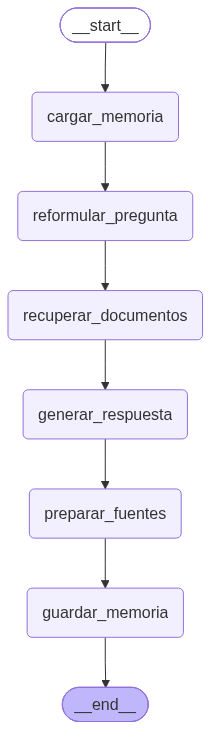

Diagrama del grafo generado correctamente.


In [70]:
# ============================================================
# LANGGRAPH: DEFINICIÓN DEL ESTADO, NODOS Y FLUJO DEL AGENTE
# ============================================================

try:
    display(
        Image(
            grafo_retcc
            .get_graph()
            .draw_mermaid_png()
        )
    )

    print("Diagrama del grafo generado correctamente.")

except Exception as error_grafico:
    print(
        "No se pudo generar la imagen PNG del grafo:",
        str(error_grafico)
    )

    print("\nCódigo Mermaid del grafo:\n")

    print(
        grafo_retcc
        .get_graph()
        .draw_mermaid()
    )


def responder_pregunta_con_memoria(
    pregunta: str,
    session_id: str = "sesion-principal"
) -> dict:
    """
    Ejecuta el flujo conversacional completo mediante
    el grafo compilado de LangGraph.
    """

    if not pregunta or not pregunta.strip():
        return {
            "pregunta_original": pregunta,
            "pregunta_reformulada": "",
            "respuesta": "Debe ingresar una pregunta.",
            "fuentes": [],
            "documentos": [],
            "session_id": session_id
        }

    pregunta = pregunta.strip()

    estado_inicial: EstadoAgenteRETCC = {
        "pregunta_original": pregunta,
        "session_id": session_id
    }

    try:
        estado_final = grafo_retcc.invoke(
            estado_inicial
        )

        return {
            "pregunta_original": estado_final.get(
                "pregunta_original",
                pregunta
            ),
            "pregunta_reformulada": estado_final.get(
                "pregunta_reformulada",
                pregunta
            ),
            "respuesta": estado_final.get(
                "respuesta",
                "No se pudo generar una respuesta."
            ),
            "fuentes": estado_final.get(
                "fuentes",
                []
            ),
            "documentos": estado_final.get(
                "documentos_recuperados",
                []
            ),
            "session_id": estado_final.get(
                "session_id",
                session_id
            )
        }

    except Exception as error:
        print(
            "Error ejecutando el grafo RETCC:",
            str(error)
        )

        return {
            "pregunta_original": pregunta,
            "pregunta_reformulada": "",
            "respuesta": (
                "Ocurrió un error al procesar la consulta."
            ),
            "fuentes": [],
            "documentos": [],
            "session_id": session_id,
            "error": str(error)
        }


def preguntar_al_agente_con_memoria(
    pregunta: str,
    session_id: str = "sesion-principal"
) -> dict:

    resultado = responder_pregunta_con_memoria(
        pregunta=pregunta,
        session_id=session_id
    )

    print("=" * 90)
    print("PREGUNTA ORIGINAL")
    print("=" * 90)
    print(resultado["pregunta_original"])

    print("\n" + "=" * 90)
    print("PREGUNTA UTILIZADA PARA BUSCAR EN FAISS")
    print("=" * 90)
    print(resultado["pregunta_reformulada"])

    print("\n" + "=" * 90)
    print("RESPUESTA")
    print("=" * 90)
    print(resultado["respuesta"])

    print("\n" + "=" * 90)
    print("FUENTES RECUPERADAS")
    print("=" * 90)

    if resultado["fuentes"]:
        for fuente in resultado["fuentes"]:
            print(
                f"- {fuente['archivo']}, "
                f"página {fuente['pagina']}"
            )
    else:
        print("No se recuperaron fuentes.")

    return resultado

In [71]:
almacen_conversaciones.clear()

print("Todas las conversaciones fueron reiniciadas.")

resultado_1 = preguntar_al_agente_con_memoria(
    pregunta="¿Cuáles son los requisitos para inscribirse en el RETCC?",
    session_id="prueba-retcc"
)

resultado_2 = preguntar_al_agente_con_memoria(
    pregunta="¿Y dónde se presenta?",
    session_id="prueba-retcc"
)

resultado_3 = preguntar_al_agente_con_memoria(
    pregunta="¿Y cuánto tiempo demora?",
    session_id="prueba-retcc"
)

def mostrar_historial(
    session_id: str = "sesion-principal"
) -> None:

    historial = obtener_historial(session_id)

    print(f"HISTORIAL DE LA SESIÓN: {session_id}")
    print("=" * 90)

    if not historial.messages:
        print("La conversación está vacía.")
        return

    for mensaje in historial.messages:

        if isinstance(mensaje, HumanMessage):
            rol = "USUARIO"

        elif isinstance(mensaje, AIMessage):
            rol = "ASISTENTE"

        else:
            rol = mensaje.__class__.__name__

        print(f"\n{rol}:")
        print(mensaje.content)

mostrar_historial("prueba-retcc")

def reiniciar_conversacion(
    session_id: str = "sesion-principal"
) -> None:

    if session_id in almacen_conversaciones:
        almacen_conversaciones[session_id].clear()

    print(
        f"Conversación '{session_id}' "
        "reiniciada correctamente."
    )

reiniciar_conversacion("prueba-retcc")

preguntar_al_agente_con_memoria(
    pregunta="¿Cuáles son los requisitos de inscripción?",
    session_id="usuario-1"
)

preguntar_al_agente_con_memoria(
    pregunta="¿Cómo se realiza la renovación?",
    session_id="usuario-2"
)

Todas las conversaciones fueron reiniciadas.
Nodo: cargar_memoria
Nodo: reformular_pregunta
Nodo: recuperar_documentos
Nodo: generar_respuesta
Nodo: preparar_fuentes
Nodo: guardar_memoria
PREGUNTA ORIGINAL
¿Cuáles son los requisitos para inscribirse en el RETCC?

PREGUNTA UTILIZADA PARA BUSCAR EN FAISS
¿Cuáles son los requisitos para inscribirse en el RETCC?

RESPUESTA
Para inscribirse en el RETCC, los trabajadores interesados deben cumplir con los siguientes requisitos:

1.  Presentar una solicitud según formato aprobado mediante resolución ministerial.
2.  Adjuntar Certificado o Constancia de Capacitación o Certificación de competencias laborales emitida por SENCICO u otras entidades públicas o privadas habilitadas para capacitar o certificar las competencias laborales en la actividad de construcción civil.
    *   La presentación de este documento no será exigible cuando se trate de la primera inscripción, lo que se indicará en la solicitud.
3.  Adjuntar Certificado o Constancia de 

{'pregunta_original': '¿Cómo se realiza la renovación?',
 'pregunta_reformulada': '',
 'respuesta': 'Ocurrió un error al procesar la consulta.',
 'fuentes': [],
 'documentos': [],
 'session_id': 'usuario-2',
 'error': "Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\\nPlease retry in 42.42284975s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.c

In [72]:
import gradio as gr

print("Versión de Gradio:", gr.__version__)

Versión de Gradio: 6.20.0
